## Глава 2. Анализ временных рядов (Кейс: Авиадвигатели NASA)
### Этап 1. Загрузка и первичный осмотр данных
В данной ячейке производится загрузка тренировочной выборки `FD001` (100 двигателей) из открытого репозитория. Данные не имеют заголовков, поэтому мы присваиваем названия 21 физическому сенсору, а также вычисляем нашу целевую переменную **RUL** (Remaining Useful Life — остаточный срок службы) для каждой строки временного ряда.

Размерность загруженного временного ряда: (20631, 27)
Количество уникальных двигателей (независимых рядов): 100

Первые 5 строк датасета:


,engine_id,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


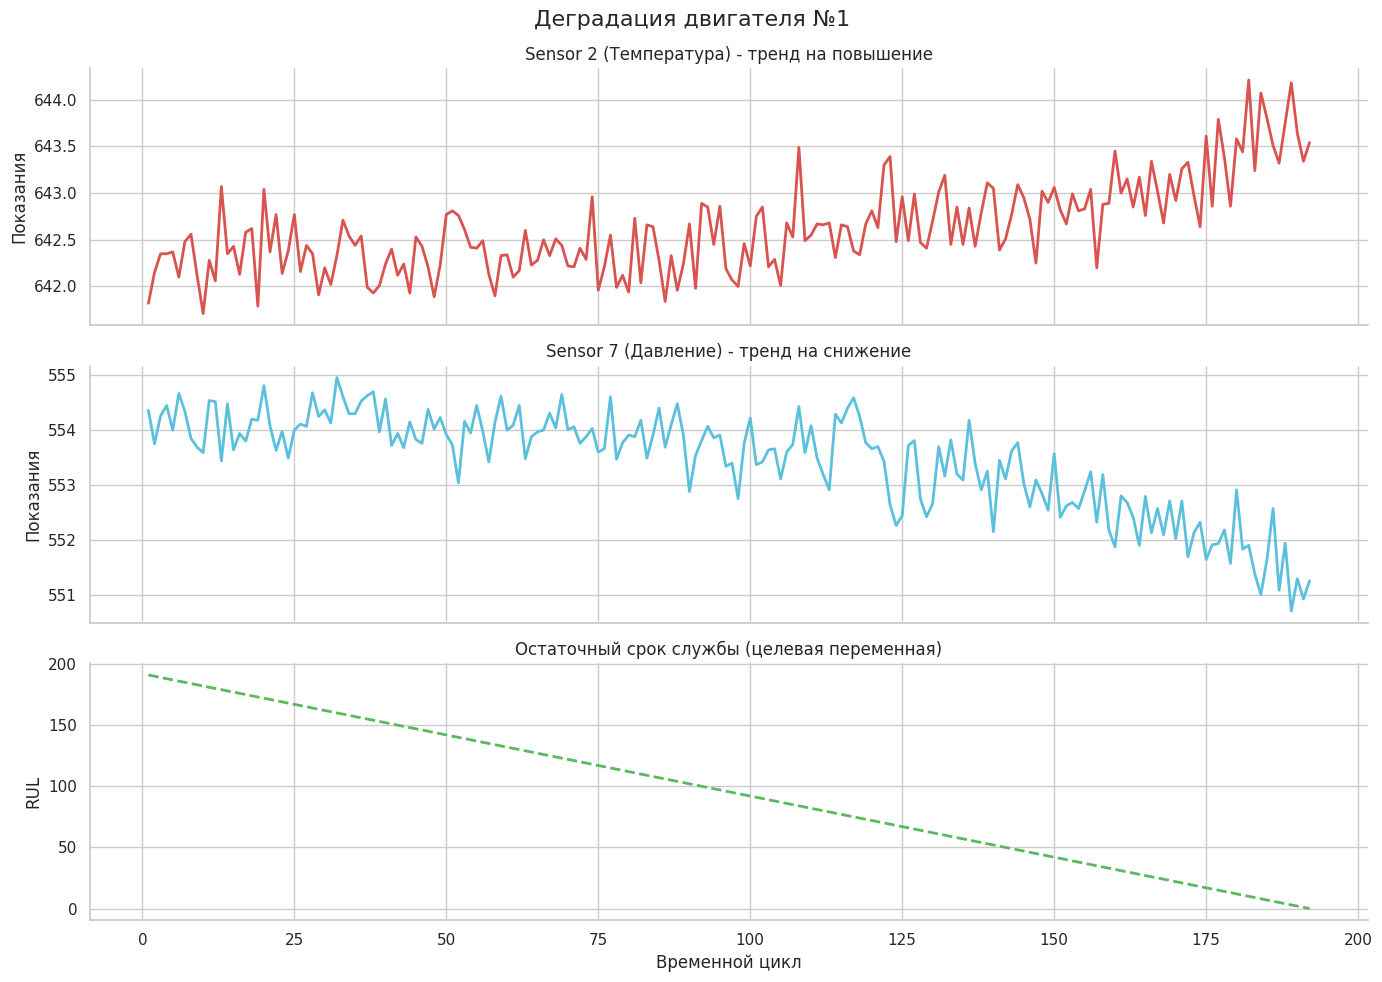

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

sb.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# 1. Загрузка данных по прямой ссылке
url_train = 'https://raw.githubusercontent.com/Sa1ronn/ET142-DenisovNU/refs/heads/main/train_FD001.txt'

# Названия колонок согласно документации NASA
columns = ['engine_id', 'time_cycle', 'setting_1', 'setting_2', 'setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

# Чтение данных (файлы разделены пробелами)
df_ts = pd.read_csv(url_train, sep=r'\s+', header=None, names=columns)

# 2. Вычисление целевой переменной RUL (Remaining Useful Life)
# RUL = (Максимальный цикл для данного двигателя) - (Текущий цикл)
rul_calc = pd.DataFrame(df_ts.groupby('engine_id')['time_cycle'].max()).reset_index()
rul_calc.columns = ['engine_id', 'max_cycle']
df_ts = df_ts.merge(rul_calc, on=['engine_id'], how='left')
df_ts['RUL'] = df_ts['max_cycle'] - df_ts['time_cycle']
df_ts.drop('max_cycle', axis=1, inplace=True)

print(f"Размерность загруженного временного ряда: {df_ts.shape}")
print(f"Количество уникальных двигателей (независимых рядов): {df_ts['engine_id'].nunique()}")
print("\nПервые 5 строк датасета:")
display(df_ts.head())

# 3. Базовая визуализация: Жизненный цикл Двигателя №1 (Run-to-Failure)
engine_1 = df_ts[df_ts['engine_id'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Деградация двигателя №1', fontsize=16, y=0.98)

# График 1: Сенсор 2 (Температура) - растет при износе
axes[0].plot(engine_1['time_cycle'], engine_1['sensor_2'], color='#d9534f', linewidth=2)
axes[0].set_title('Sensor 2 (Температура) - тренд на повышение', fontsize=12)
axes[0].set_ylabel('Показания')

# График 2: Сенсор 7 (Давление) - падает при износе
axes[1].plot(engine_1['time_cycle'], engine_1['sensor_7'], color='#5bc0de', linewidth=2)
axes[1].set_title('Sensor 7 (Давление) - тренд на снижение', fontsize=12)
axes[1].set_ylabel('Показания')

# График 3: Целевая переменная (RUL)
axes[2].plot(engine_1['time_cycle'], engine_1['RUL'], color='#5cb85c', linewidth=2, linestyle='--')
axes[2].set_title('Остаточный срок службы (целевая переменная)', fontsize=12)
axes[2].set_xlabel('Временной цикл')
axes[2].set_ylabel('RUL')

plt.tight_layout()
plt.show()

## Этапы 3, 4 и 5: Статистика, пропуски и анализ масштабов
Проверка данных на пропуски, выявление неинформативных датчиков (констант) и визуализация колоссальной разницы в масштабах физических измерений.

АНАЛИЗ ПРОПУСКОВ
Общее количество пропущенных значений (NaN) во всем датасете: 0

СТАТИСТИЧЕСКИЙ АНАЛИЗ
Обнаружены неинформативные каналы (константы со std=0): ['setting_3', 'sensor_18', 'sensor_19']
Они будут исключены из дальнейшего визуального анализа.


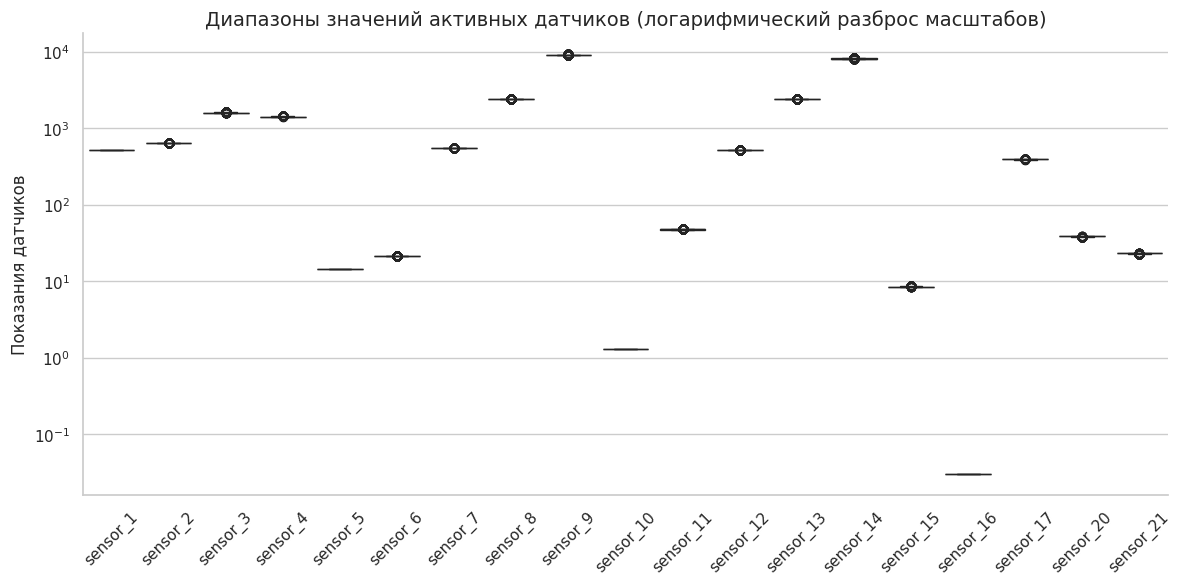

In [ ]:
# 4: Пропуски
print("АНАЛИЗ ПРОПУСКОВ")
missing_vals = df_ts.isnull().sum().sum()
print(f"Общее количество пропущенных значений (NaN) во всем датасете: {missing_vals}")

# 3: Статистика и поиск "мертвых" датчиков (std == 0)
print("\nСТАТИСТИЧЕСКИЙ АНАЛИЗ")
describe_df = df_ts.describe().T
flat_sensors = describe_df[describe_df['std'] == 0].index.tolist()
print(f"Обнаружены неинформативные каналы (константы со std=0): {flat_sensors}")
print("Они будут исключены из дальнейшего визуального анализа.")

# 5: Анализ диапазонов (Диаграмма размаха)
# Оставляем только физические сенсоры, которые меняются
active_sensors = [col for col in df_ts.columns if 'sensor' in col and col not in flat_sensors]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_ts[active_sensors], palette='viridis')
plt.title('Диапазоны значений активных датчиков (логарифмический разброс масштабов)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Показания датчиков')
plt.yscale('log')
# Используем лог-шкалу, иначе мелкие датчики сольются в линию из-за датчиков на 8000+
plt.show()

## Этап 6: Корреляционный анализ
Построение тепловой карты для активных датчиков и целевой переменной RUL.

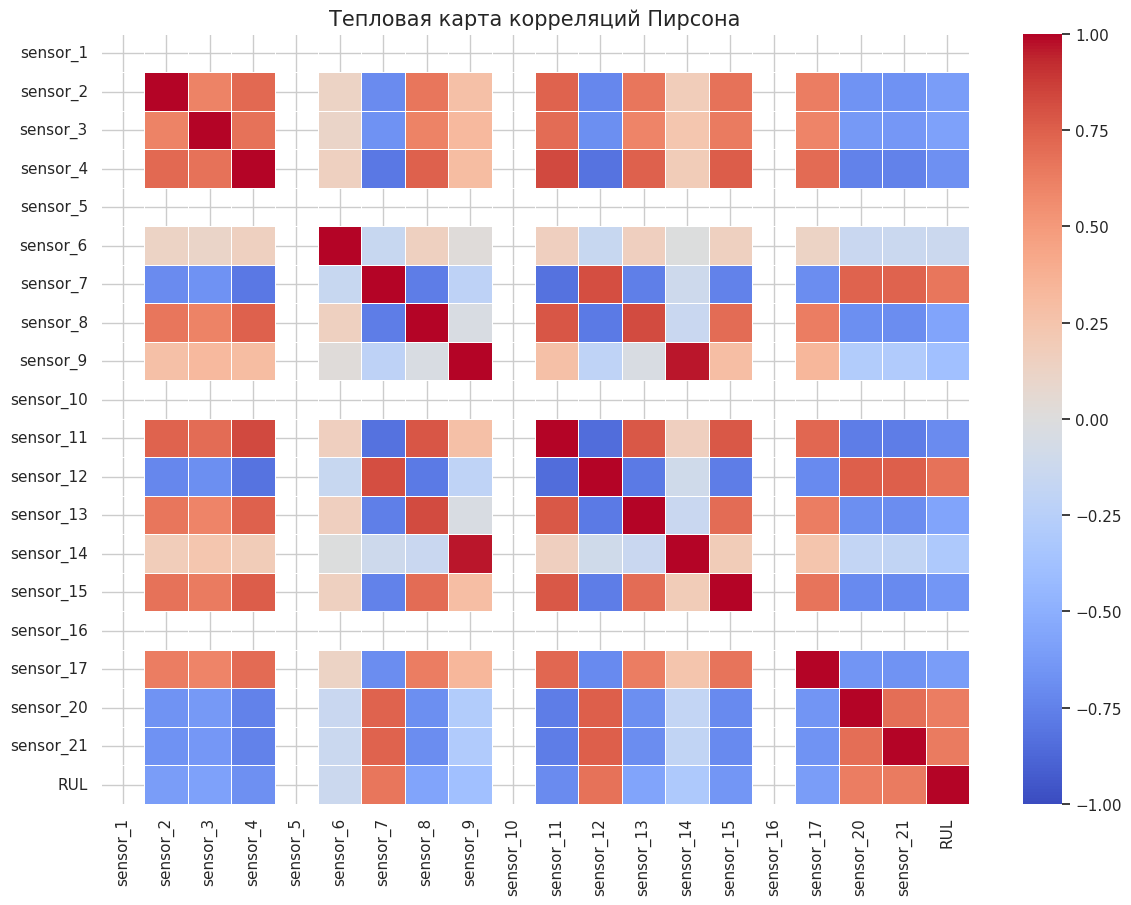

In [ ]:
# 6: Корреляционный анализ
plt.figure(figsize=(14, 10))

# Берем активные сенсоры + целевую RUL
corr_cols = active_sensors + ['RUL']
corr_matrix = df_ts[corr_cols].corr()

# Строим тепловую карту
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Тепловая карта корреляций Пирсона', fontsize=15)
plt.show()

## Этап 7: Поиск и анализ шумов (Декомпозиция)
Разложение сигнала температуры (sensor_2) на тренд и шум с помощью seasonal_decompose. Расчет отношения Сигнал/Шум (SNR).

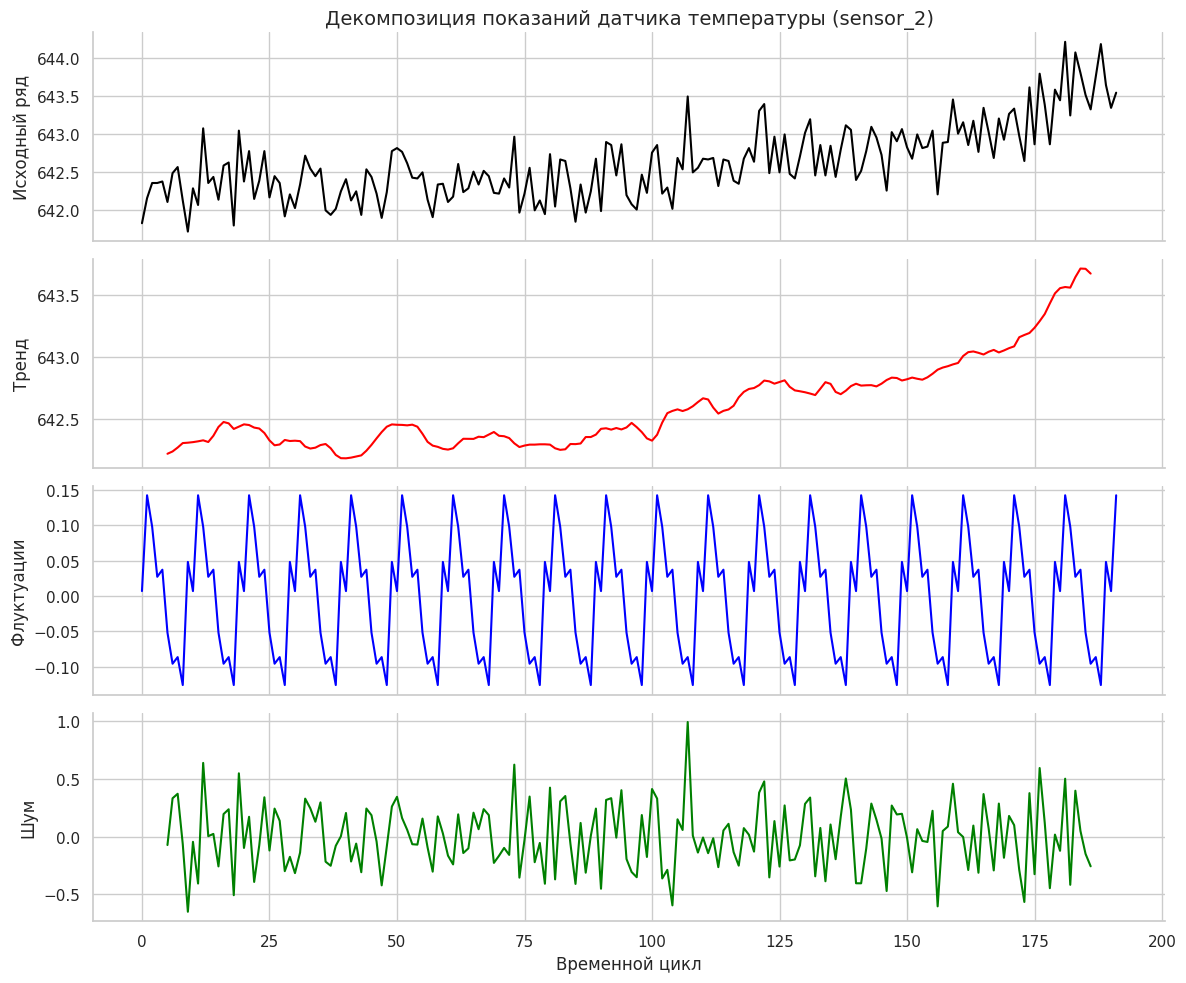

РАСЧЕТ SNR
Дисперсия сигнала: 0.1317
Дисперсия шума: 0.0806
Отношение сигнал/шум (SNR): 2.13 дБ


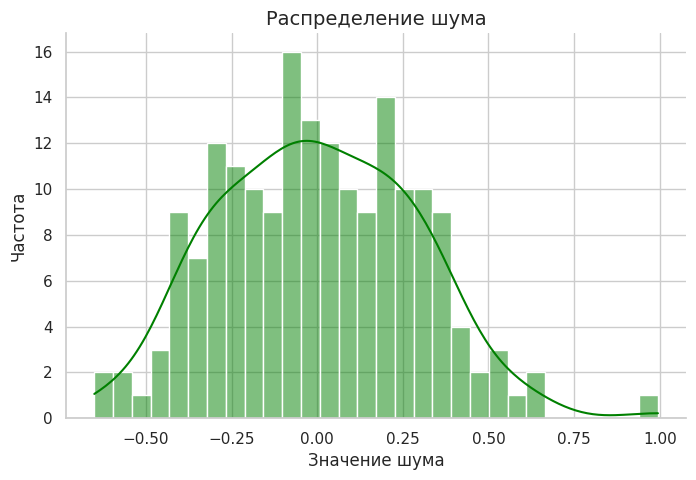

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Берем жизненный цикл одного двигателя (№1) и один ключевой датчик температуры (sensor_2)
engine_data = df_ts[df_ts['engine_id'] == 1]['sensor_2'].values

# Декомпозиция (period=10 циклов для улавливания локальных микроколебаний режимов)
result = seasonal_decompose(engine_data, model='additive', period=10)

# Графики декомпозиции
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(result.observed, color='black')
axes[0].set_ylabel('Исходный ряд')
axes[0].set_title('Декомпозиция показаний датчика температуры (sensor_2)', fontsize=14)

axes[1].plot(result.trend, color='red')
axes[1].set_ylabel('Тренд')

axes[2].plot(result.seasonal, color='blue')
axes[2].set_ylabel('Флуктуации')

axes[3].plot(result.resid, color='green')
axes[3].set_ylabel('Шум')
axes[3].set_xlabel('Временной цикл')
plt.tight_layout()
plt.show()

# Расчет SNR (Signal-to-Noise Ratio)
# Сигнал = Исходный ряд без остатков (Тренд + Флуктуации)
# Из-за period=10 в начале и конце тренда есть NaN, отсекаем их
valid_idx = ~np.isnan(result.resid)
signal = result.trend[valid_idx] + result.seasonal[valid_idx]
noise = result.resid[valid_idx]

var_signal = np.var(signal)
var_noise = np.var(noise)
snr_db = 10 * np.log10(var_signal / var_noise)

print(f"РАСЧЕТ SNR")
print(f"Дисперсия сигнала: {var_signal:.4f}")
print(f"Дисперсия шума: {var_noise:.4f}")
print(f"Отношение сигнал/шум (SNR): {snr_db:.2f} дБ")

# Распределение остатков
plt.figure(figsize=(8, 5))
sns.histplot(noise, kde=True, color='green', bins=30)
plt.title('Распределение шума', fontsize=14)
plt.xlabel('Значение шума')
plt.ylabel('Частота')
plt.show()